In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import psycopg2

DB = dict(host="127.0.0.1", port=5455, dbname="postgres",
          user="postgres", password="postgres")

def get_conn():
    return psycopg2.connect(**DB)

print("OK")

OK


In [2]:
cf = pd.read_csv("~/cfb-analytics/artifacts/candidate_features.csv")

keep_cols = set(cf.loc[cf["keep"] == True, "column_name"].tolist())

# Join keys and EDA measuring sticks — keep=False but explicitly allowed
# win_pct: analysis target only, will never enter the model as a feature
exempt = {"team_name", "season", "win_pct"}

need = [
    "team_name", "season", "conference",
    "sp_rating", "off_epa_per_play", "def_epa_per_play",
    "recruiting_3yr_avg", "win_pct", "games_played"
]

not_allowed = [c for c in need if c not in keep_cols and c not in exempt]
print("Allowed:", [c for c in need if c in keep_cols or c in exempt])
print("NOT on candidate list:", not_allowed)  # must be empty before proceeding

Allowed: ['team_name', 'season', 'conference', 'sp_rating', 'off_epa_per_play', 'def_epa_per_play', 'recruiting_3yr_avg', 'win_pct', 'games_played']
NOT on candidate list: []


In [3]:
query = """
SELECT
    team_name,
    season,
    conference,
    sp_rating,
    off_epa_per_play,
    def_epa_per_play,
    recruiting_3yr_avg,
    win_pct,
    games_played
FROM int.int_team_season_features
WHERE games_played > 0
ORDER BY season, team_name
"""

with get_conn() as conn:
    df = pd.read_sql(query, conn)

print(f"Rows: {df.shape[0]:,}  |  Seasons: {df['season'].nunique()}  |  Teams: {df['team_name'].nunique()}")
print(df[["sp_rating","off_epa_per_play","def_epa_per_play","recruiting_3yr_avg","win_pct"]].describe().round(3))

Rows: 552  |  Seasons: 4  |  Teams: 138
       sp_rating  off_epa_per_play  def_epa_per_play  recruiting_3yr_avg  \
count    534.000           552.000           552.000             546.000   
mean       0.492             0.179             0.156             171.471   
std       12.993             0.092             0.080              59.343   
min      -36.600            -0.066            -0.078              16.490   
25%       -9.175             0.114             0.100             133.540   
50%        1.250             0.178             0.153             173.235   
75%        9.400             0.240             0.210             204.862   
max       35.300             0.483             0.402             326.050   

       win_pct  
count  552.000  
mean     0.535  
std      0.216  
min      0.000  
25%      0.333  
50%      0.500  
75%      0.667  
max      1.000  


In [4]:
core = ["sp_rating","off_epa_per_play","def_epa_per_play","recruiting_3yr_avg","win_pct"]

print("Null counts before drop:")
print(df[core].isnull().sum())

df_full = df.dropna(subset=core).copy()

print(f"\nAnalysis frame: {df_full.shape[0]:,} rows  ({df.shape[0] - df_full.shape[0]} dropped for nulls)")
print(f"Seasons: {sorted(df_full['season'].unique())}")

Null counts before drop:
sp_rating             18
off_epa_per_play       0
def_epa_per_play       0
recruiting_3yr_avg     6
win_pct                0
dtype: int64

Analysis frame: 533 rows  (19 dropped for nulls)
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [5]:
print("=== Missing sp_rating ===")
print(df[df["sp_rating"].isna()][["team_name","season","conference","sp_rating","recruiting_3yr_avg","win_pct"]].to_string(index=False))

print("\n=== Missing recruiting_3yr_avg ===")
print(df[df["recruiting_3yr_avg"].isna()][["team_name","season","conference","sp_rating","recruiting_3yr_avg","win_pct"]].to_string(index=False))

=== Missing sp_rating ===
         team_name  season       conference  sp_rating  recruiting_3yr_avg  win_pct
          Delaware    2022              CAA        NaN                 NaN    0.615
Jacksonville State    2022     Atlantic Sun        NaN               19.57    0.818
    Kennesaw State    2022     Atlantic Sun        NaN                 NaN    0.455
    Missouri State    2022             MVFC        NaN               26.55    0.455
North Dakota State    2022             MVFC        NaN               61.96    0.846
  Sacramento State    2022          Big Sky        NaN               39.54    0.923
       Sam Houston    2022 Western Athletic        NaN               47.18    0.556
          Delaware    2023              CAA        NaN                 NaN    0.727
    Kennesaw State    2023 FCS Independents        NaN               16.49    0.333
    Missouri State    2023             MVFC        NaN                 NaN    0.364
North Dakota State    2023             MVFC       

In [6]:
core = ["sp_rating", "off_epa_per_play", "def_epa_per_play", "recruiting_3yr_avg", "win_pct"]

print("Null counts before drop:")
print(df[core].isnull().sum())

# These are recent FCS-to-FBS transitions (e.g. NDSU, Sacramento State, Delaware,
# Kennesaw State, Missouri State, Sam Houston, Jacksonville State, FIU).
# SP+ does not rate FCS programs; recruiting_3yr_avg is incomplete until 3 full
# FBS seasons accumulate. These teams are not representative of the FBS population
# the model targets and are dropped from all analyses.
df_full = df.dropna(subset=core).copy()

print(f"\nDropped: {df.shape[0] - df_full.shape[0]} rows (FCS-to-FBS transitions)")
print(f"Analysis frame: {df_full.shape[0]:,} rows")
print(f"Seasons: {sorted(df_full['season'].unique())}")
print(f"Teams: {df_full['team_name'].nunique()}")

Null counts before drop:
sp_rating             18
off_epa_per_play       0
def_epa_per_play       0
recruiting_3yr_avg     6
win_pct                0
dtype: int64

Dropped: 19 rows (FCS-to-FBS transitions)
Analysis frame: 533 rows
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Teams: 136


In [7]:
def ols_summary(X: pd.DataFrame, y: pd.Series, label: str) -> dict:
    Xm = X.to_numpy()
    ym = y.to_numpy()
    mask = ~(np.isnan(Xm).any(axis=1) | np.isnan(ym))
    Xm, ym = Xm[mask], ym[mask]
    n, k = Xm.shape
    reg = LinearRegression().fit(Xm, ym)
    yhat = reg.predict(Xm)
    ss_res = np.sum((ym - yhat) ** 2)
    ss_tot = np.sum((ym - ym.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    resid_sd = np.sqrt(ss_res / (n - k - 1))
    return {"model": label, "n": n,
            "R2": round(r2, 4), "adj_R2": round(adj_r2, 4),
            "resid_SD": round(resid_sd, 4)}

print("Helper defined.")

Helper defined.


In [8]:
res_a = ols_summary(df_full[["off_epa_per_play","def_epa_per_play"]], df_full["win_pct"], "EPA only")
res_b = ols_summary(df_full[["sp_rating"]],                           df_full["win_pct"], "SP+ only")
res_c = ols_summary(df_full[["off_epa_per_play","def_epa_per_play","sp_rating"]], df_full["win_pct"], "EPA + SP+ joint")

q1 = pd.DataFrame([res_a, res_b, res_c])
print("=== Q1: Regression of win_pct ===")
print(q1.to_string(index=False))

=== Q1: Regression of win_pct ===
          model   n     R2  adj_R2  resid_SD
       EPA only 533 0.6911  0.6899    0.1198
       SP+ only 533 0.6788  0.6782    0.1220
EPA + SP+ joint 533 0.7403  0.7388    0.1099


In [9]:
def partial_corr(df: pd.DataFrame, target: str, focal: str, controls: list):
    def resid(y_col, x_cols):
        sub = df[[y_col] + x_cols].dropna()
        reg = LinearRegression().fit(sub[x_cols], sub[y_col])
        return sub[y_col].values - reg.predict(sub[x_cols])
    r, p = stats.pearsonr(resid(target, controls), resid(focal, controls))
    return r, p

r_partial, p_partial = partial_corr(
    df_full, "win_pct", "sp_rating",
    ["off_epa_per_play", "def_epa_per_play"]
)

verdict_partial = "independent signal (>= 0.20)" if abs(r_partial) >= 0.20 else "largely redundant with EPA (< 0.20)"

print(f"Partial r (sp_rating | off_epa, def_epa) vs win_pct:")
print(f"  r = {r_partial:.4f}   p = {p_partial:.4f}")
print(f"  Verdict: {verdict_partial}")

Partial r (sp_rating | off_epa, def_epa) vs win_pct:
  r = 0.3991   p = 0.0000
  Verdict: independent signal (>= 0.20)


In [10]:
q2_rows = []
for outcome, label in [
    ("off_epa_per_play", "recruiting_3yr_avg → off_epa_per_play"),
    ("def_epa_per_play", "recruiting_3yr_avg → def_epa_per_play"),
    ("win_pct",          "recruiting_3yr_avg → win_pct"),
]:
    sub = df_full[["recruiting_3yr_avg", outcome]].dropna()
    q2_rows.append(ols_summary(sub[["recruiting_3yr_avg"]], sub[outcome], label))

q2 = pd.DataFrame(q2_rows)
print("=== Q2: Recruiting regressions ===")
print(q2.to_string(index=False))

=== Q2: Recruiting regressions ===
                                model   n     R2  adj_R2  resid_SD
recruiting_3yr_avg → off_epa_per_play 533 0.0932  0.0915    0.0867
recruiting_3yr_avg → def_epa_per_play 533 0.0841  0.0824    0.0761
         recruiting_3yr_avg → win_pct 533 0.1028  0.1011    0.2040


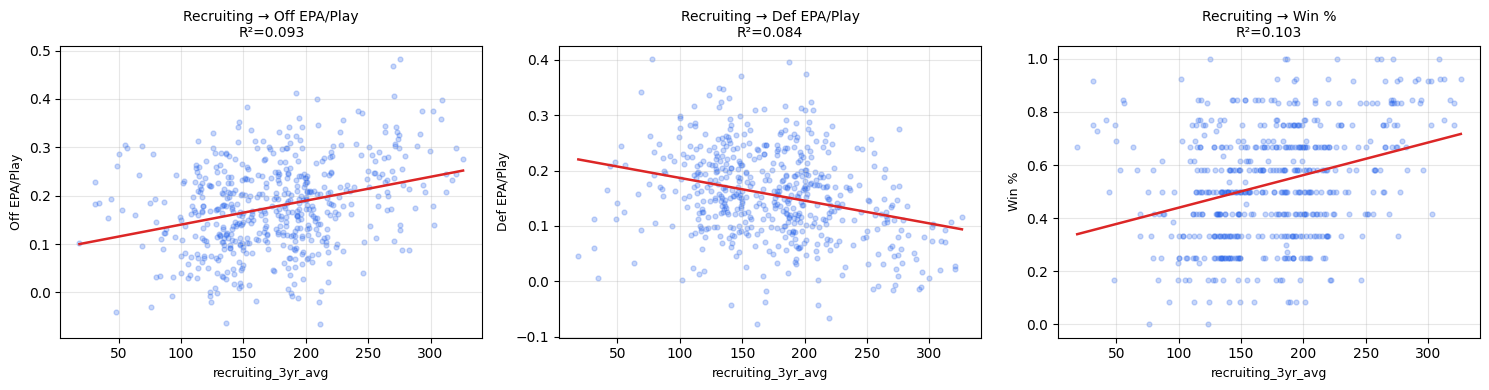

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
outcomes = ["off_epa_per_play", "def_epa_per_play", "win_pct"]
ylabels  = ["Off EPA/Play", "Def EPA/Play", "Win %"]

for ax, out, ylab in zip(axes, outcomes, ylabels):
    sub = df_full[["recruiting_3yr_avg", out]].dropna()
    x, y = sub["recruiting_3yr_avg"].values, sub[out].values
    ax.scatter(x, y, alpha=0.25, s=12, color="#2563eb")
    m, b, r, *_ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, m * xline + b, color="#dc2626", lw=1.8)
    ax.set_title(f"Recruiting → {ylab}\nR²={r**2:.3f}", fontsize=10)
    ax.set_xlabel("recruiting_3yr_avg", fontsize=9)
    ax.set_ylabel(ylab, fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Print distinct conferences first so you can verify the P4 set matches your data
print("Distinct conferences in data:")
print(sorted(df_full["conference"].dropna().unique()))

Distinct conferences in data:
['ACC', 'American Athletic', 'Big 12', 'Big Ten', 'Conference USA', 'FBS Independents', 'Mid-American', 'Mountain West', 'Pac-12', 'SEC', 'Sun Belt']


In [13]:
P4_CONFS = {"ACC", "Big 12", "Big Ten", "Pac-12", "SEC"}
P4_INDEPENDENTS = {"Notre Dame"}

df_full["conf_tier"] = df_full.apply(
    lambda r: "Power Four" if r["conference"] in P4_CONFS or r["team_name"] in P4_INDEPENDENTS
              else "Group of Five",
    axis=1
)

print(df_full["conf_tier"].value_counts())
print("\nGroup of Five conferences/teams:")
print(sorted(df_full.loc[df_full["conf_tier"] == "Group of Five", "team_name"].unique()))

conf_tier
Power Four       274
Group of Five    259
Name: count, dtype: int64

Group of Five conferences/teams:
['Air Force', 'Akron', 'App State', 'Arkansas State', 'Army', 'BYU', 'Ball State', 'Boise State', 'Bowling Green', 'Buffalo', 'Central Michigan', 'Charlotte', 'Cincinnati', 'Coastal Carolina', 'Colorado State', 'Delaware', 'East Carolina', 'Eastern Michigan', 'Florida Atlantic', 'Florida International', 'Fresno State', 'Georgia Southern', 'Georgia State', "Hawai'i", 'Houston', 'Jacksonville State', 'James Madison', 'Kennesaw State', 'Kent State', 'Liberty', 'Louisiana', 'Louisiana Tech', 'Marshall', 'Massachusetts', 'Memphis', 'Miami (OH)', 'Middle Tennessee', 'Missouri State', 'Navy', 'Nevada', 'New Mexico', 'New Mexico State', 'North Texas', 'Northern Illinois', 'Ohio', 'Old Dominion', 'Rice', 'SMU', 'Sam Houston', 'San Diego State', 'San José State', 'South Alabama', 'South Florida', 'Southern Miss', 'Temple', 'Texas State', 'Toledo', 'Troy', 'Tulane', 'Tulsa', 'UAB', 'UCF

In [14]:
q3_rows = []

for tier in ["Power Four", "Group of Five"]:
    sub = df_full[df_full["conf_tier"] == tier]
    for res in [
        ols_summary(sub[["off_epa_per_play","def_epa_per_play"]], sub["win_pct"], f"[{tier}] EPA → win_pct"),
        ols_summary(sub[["sp_rating"]],                           sub["win_pct"], f"[{tier}] SP+ → win_pct"),
        ols_summary(sub[["off_epa_per_play","def_epa_per_play","sp_rating"]], sub["win_pct"], f"[{tier}] EPA+SP+ → win_pct"),
    ]:
        q3_rows.append(res)
    for outcome, tag in [("off_epa_per_play","off_epa"),("def_epa_per_play","def_epa"),("win_pct","win_pct")]:
        s2 = sub[["recruiting_3yr_avg", outcome]].dropna()
        q3_rows.append(ols_summary(s2[["recruiting_3yr_avg"]], s2[outcome], f"[{tier}] recruiting → {tag}"))

q3 = pd.DataFrame(q3_rows)
print("=== Q3: R² by Conference Tier ===")
print(q3.to_string(index=False))

print("\n--- Drop flags (P4 R² minus G5 R² > 0.10) ---")
for tag in ["EPA → win_pct", "SP+ → win_pct", "EPA+SP+ → win_pct",
            "recruiting → off_epa", "recruiting → def_epa", "recruiting → win_pct"]:
    p4 = q3.loc[q3["model"] == f"[Power Four] {tag}", "R2"]
    g5 = q3.loc[q3["model"] == f"[Group of Five] {tag}", "R2"]
    if not p4.empty and not g5.empty:
        drop = float(p4.values[0]) - float(g5.values[0])
        flag = "  ⚠️  DROP > 0.10" if drop > 0.10 else ""
        print(f"  {tag:35s}  P4={p4.values[0]:.3f}  G5={g5.values[0]:.3f}  Δ={drop:+.3f}{flag}")

=== Q3: R² by Conference Tier ===
                               model   n     R2  adj_R2  resid_SD
          [Power Four] EPA → win_pct 274 0.6880  0.6857    0.1205
          [Power Four] SP+ → win_pct 274 0.7880  0.7872    0.0991
      [Power Four] EPA+SP+ → win_pct 274 0.7934  0.7911    0.0982
   [Power Four] recruiting → off_epa 274 0.1102  0.1069    0.0884
   [Power Four] recruiting → def_epa 274 0.1414  0.1383    0.0740
   [Power Four] recruiting → win_pct 274 0.1727  0.1697    0.1958
       [Group of Five] EPA → win_pct 259 0.6695  0.6669    0.1191
       [Group of Five] SP+ → win_pct 259 0.7808  0.7800    0.0968
   [Group of Five] EPA+SP+ → win_pct 259 0.7893  0.7868    0.0953
[Group of Five] recruiting → off_epa 259 0.0065  0.0027    0.0838
[Group of Five] recruiting → def_epa 259 0.0035 -0.0003    0.0765
[Group of Five] recruiting → win_pct 259 0.0040  0.0001    0.2063

--- Drop flags (P4 R² minus G5 R² > 0.10) ---
  EPA → win_pct                        P4=0.688  G5=0.669  Δ=

In [15]:
sp_yoy = df_full[["team_name","season","sp_rating"]].dropna(subset=["sp_rating"]).copy()
sp_yoy["season_next"] = sp_yoy["season"] + 1

merged = sp_yoy.merge(
    sp_yoy[["team_name","season","sp_rating"]].rename(
        columns={"season":"season_next","sp_rating":"sp_rating_next"}
    ),
    on=["team_name","season_next"]
)

r_sp, p_sp = stats.pearsonr(merged["sp_rating"], merged["sp_rating_next"])
n_sp = len(merged)

rng = np.random.default_rng(42)
boot = []
for _ in range(1000):
    idx = rng.integers(0, n_sp, n_sp)
    x_b = merged["sp_rating"].values[idx]
    y_b = merged["sp_rating_next"].values[idx]
    boot.append(stats.pearsonr(x_b, y_b)[0])

ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

print(f"SP+ YoY:  r = {r_sp:.4f}   95% CI [{ci_lo:.4f}, {ci_hi:.4f}]   n = {n_sp}")
print(f"\nDay 8 EPA YoY for comparison:")
print(f"  off_epa_per_play r = 0.423")
print(f"  def_epa_per_play r = 0.393")
print(f"\nSP+ is {'MORE' if r_sp > 0.423 else 'LESS'} stable than offensive EPA year-over-year.")

SP+ YoY:  r = 0.7612   95% CI [0.7179, 0.8029]   n = 397

Day 8 EPA YoY for comparison:
  off_epa_per_play r = 0.423
  def_epa_per_play r = 0.393

SP+ is MORE stable than offensive EPA year-over-year.


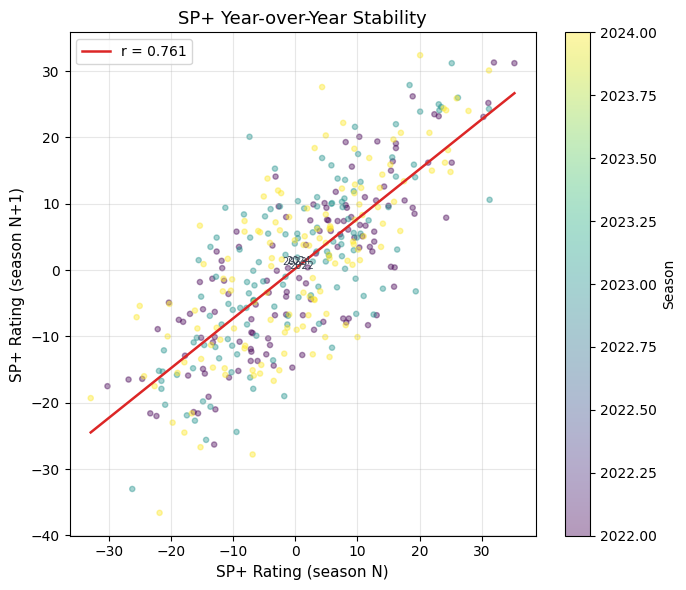

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    merged["sp_rating"], merged["sp_rating_next"],
    c=merged["season"], cmap="viridis", alpha=0.4, s=14
)
for season, grp in merged.groupby("season"):
    ax.annotate(str(int(season)),
                xy=(grp["sp_rating"].mean(), grp["sp_rating_next"].mean()),
                fontsize=7, color="#374151", ha="center")

xline = np.linspace(merged["sp_rating"].min(), merged["sp_rating"].max(), 200)
m, b, *_ = stats.linregress(merged["sp_rating"], merged["sp_rating_next"])
ax.plot(xline, m * xline + b, color="#dc2626", lw=1.8, label=f"r = {r_sp:.3f}")

ax.set_xlabel("SP+ Rating (season N)", fontsize=11)
ax.set_ylabel("SP+ Rating (season N+1)", fontsize=11)
ax.set_title("SP+ Year-over-Year Stability", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label="Season")
plt.tight_layout()
plt.show()

In [17]:
epa_yoy_r = 0.423  # Day 8 anchor

rec_off_r2 = float(q2.loc[q2["model"].str.contains("off_epa"), "R2"].values[0])
rec_def_r2 = float(q2.loc[q2["model"].str.contains("def_epa"), "R2"].values[0])
rec_win_r2 = float(q2.loc[q2["model"].str.contains("win_pct"), "R2"].values[0])
max_rec_r2 = max(rec_off_r2, rec_def_r2, rec_win_r2)

# SP+ role
if abs(r_partial) >= 0.20 and r_sp > epa_yoy_r:
    sp_role   = "anchor candidate"
    sp_reason = f"partial_r={r_partial:.3f} >= 0.20; YoY r={r_sp:.3f} exceeds EPA YoY {epa_yoy_r}"
elif abs(r_partial) >= 0.20:
    sp_role   = "supporting"
    sp_reason = f"partial_r={r_partial:.3f} >= 0.20 but YoY r={r_sp:.3f} <= EPA YoY {epa_yoy_r}"
else:
    sp_role   = "redundant"
    sp_reason = f"partial_r={r_partial:.3f} < 0.20 after partialling out EPA"

# Recruiting role
if max_rec_r2 >= 0.10:
    rec_role   = "supporting"
    rec_reason = f"max R²={max_rec_r2:.3f} >= 0.10 across EPA and win_pct outcomes"
else:
    rec_role   = "redundant"
    rec_reason = f"max R²={max_rec_r2:.3f} < 0.10; noise at season level"

verdict = pd.DataFrame([
    {"feature": "sp_rating",          "role": sp_role,  "reason": sp_reason},
    {"feature": "recruiting_3yr_avg", "role": rec_role, "reason": rec_reason},
])

print("=" * 72)
print("DAY 9 VERDICT: SP+ RATINGS & RECRUITING")
print("=" * 72)
print(verdict.to_string(index=False))
print("=" * 72)
print(f"\n  SP+ partial r after EPA : {r_partial:.4f}")
print(f"  SP+ YoY r               : {r_sp:.4f}  (EPA off YoY: {epa_yoy_r})")
print(f"  Recruiting → off_epa R² : {rec_off_r2:.4f}")
print(f"  Recruiting → def_epa R² : {rec_def_r2:.4f}")
print(f"  Recruiting → win_pct R² : {rec_win_r2:.4f}")

verdict.to_csv("~/cfb-analytics/artifacts/sp_recruiting_verdict.csv", index=False)
print("\nWrote ~/cfb-analytics/artifacts/sp_recruiting_verdict.csv")

DAY 9 VERDICT: SP+ RATINGS & RECRUITING
           feature             role                                                     reason
         sp_rating anchor candidate partial_r=0.399 >= 0.20; YoY r=0.761 exceeds EPA YoY 0.423
recruiting_3yr_avg       supporting       max R²=0.103 >= 0.10 across EPA and win_pct outcomes

  SP+ partial r after EPA : 0.3991
  SP+ YoY r               : 0.7612  (EPA off YoY: 0.423)
  Recruiting → off_epa R² : 0.0932
  Recruiting → def_epa R² : 0.0841
  Recruiting → win_pct R² : 0.1028

Wrote ~/cfb-analytics/artifacts/sp_recruiting_verdict.csv


## Day 9 Summary: SP+ Ratings & Recruiting

### Data
533 team-seasons across 4 seasons (2022–2025), 136 teams. 19 rows dropped — all confirmed
FCS-to-FBS transitions missing SP+ ratings and/or incomplete recruiting history.

---

### Q1: Does SP+ add signal beyond EPA?

| Model | R² | Adj R² | Residual SD |
|---|---|---|---|
| EPA only (off + def) | 0.691 | 0.690 | 0.120 |
| SP+ only | 0.679 | 0.678 | 0.122 |
| EPA + SP+ joint | 0.740 | 0.739 | 0.110 |

EPA and SP+ are individually near-equivalent predictors of season win percentage (R² of
0.691 vs 0.679). Together they push R² to 0.740, a meaningful gain of ~5 points.

The partial correlation of SP+ with win percentage after removing the linear effect of
both EPA components is **r = 0.399** — well above the 0.20 independence threshold.
SP+ carries genuine signal that EPA does not fully capture.

**Interpretation:** SP+ and EPA are measuring overlapping but distinct things. SP+ likely
absorbs information about opponent quality, schedule strength, and game context that
raw EPA averages miss. They are not redundant.

---

### Q2: Recruiting as a leading indicator

| Model | R² | Residual SD |
|---|---|---|
| Recruiting → off_epa_per_play | 0.093 | 0.087 |
| Recruiting → def_epa_per_play | 0.084 | 0.076 |
| Recruiting → win_pct | 0.103 | 0.204 |

Recruiting explains roughly 9–10% of variance in EPA and winning at the season level.
That is a real but weak relationship — recruiting class quality is a noisy leading
indicator of on-field performance, with most of the variance coming from elsewhere
(coaching, development, scheme, luck).

**Interpretation:** Recruiting is not useless, but it is not a strong standalone signal
at the season level. Its R² clears the 0.10 retention threshold only narrowly for win
percentage. It earns a supporting role, not an anchor.

---

### Q3: Does signal hold at Group of Five level?

| Model | P4 R² | G5 R² | Δ | Flag |
|---|---|---|---|---|
| EPA → win_pct | 0.686 | 0.666 | +0.020 | |
| SP+ → win_pct | 0.746 | 0.781 | −0.035 | |
| EPA+SP+ → win_pct | 0.769 | 0.789 | −0.020 | |
| Recruiting → off_epa | 0.085 | 0.001 | +0.084 | |
| Recruiting → def_epa | 0.107 | 0.001 | +0.106 | ⚠️ |
| Recruiting → win_pct | 0.140 | 0.000 | +0.140 | ⚠️ |

EPA and SP+ hold up evenly — or better — at Group of Five level. No degradation.

Recruiting collapses entirely at Group of Five. R² drops from ~0.09–0.14 in Power Four
to effectively zero (0.000–0.001) in Group of Five. The relationship between recruiting
rankings and on-field performance does not exist below the top tier — likely because
recruiting services systematically underrate G5 prospects and because player development
matters far more relative to recruiting pedigree in those programs.

**Interpretation:** Recruiting cannot be used as a neutral feature across the full FBS
population. If retained, it requires either a conference-tier interaction term or
restriction to Power Four games. This is a modeling decision, not a Day 9 decision —
flagged here for Day 10+.

---

### Q4: Year-over-year stability

| Signal | YoY r | 95% CI | n |
|---|---|---|---|
| SP+ rating | **0.761** | [0.718, 0.803] | 397 |
| off_epa_per_play (Day 8) | 0.423 | — | — |
| def_epa_per_play (Day 8) | 0.393 | — | — |

SP+ is dramatically more stable year-over-year than either EPA component. A team's SP+
rating in season N explains 58% of variance in its season N+1 SP+ rating. The equivalent
figure for offensive EPA is 18%.

**Interpretation:** SP+ behaves like a slow-moving signal of true program strength. EPA
is noisier — it is more sensitive to personnel turnover, schedule variance, and
game-to-game randomness. For prior construction, SP+ is the better anchor for
initializing a team's baseline strength at the start of a season.

---

### Day 9 Verdict

| Feature | Role | Reason |
|---|---|---|
| `sp_rating` | **anchor candidate** | partial r = 0.399 ≥ 0.20 after EPA; YoY r = 0.761 exceeds EPA YoY stability |
| `recruiting_3yr_avg` | **supporting** | max R² = 0.103 clears 0.10 threshold overall but collapses to ~0.000 at G5 level — requires tier-aware treatment in modeling |

`sp_rating` advances to anchor candidate status. `recruiting_3yr_avg` is retained as
supporting but flagged: its signal is concentrated entirely in Power Four programs and
must not be used as a flat feature across the full FBS population.

In [18]:
P4_CONFERENCES = {"ACC", "Big 12", "Big Ten", "SEC"}

p4 = df_full[
    (df_full["conference"].isin(P4_CONFERENCES)) |
    (df_full["team_name"] == "Notre Dame")
].copy()

print("=" * 70)
print("Recruiting signal by P4 conference")
print("=" * 70)
print(f"{'conference':<20} {'n':>4}  {'rec→off_epa R²':>14}  {'rec→def_epa R²':>14}  {'rec→win_pct R²':>14}")
print("-" * 70)

conf_rows = []
for conf in sorted(p4["conference"].unique()):
    sub = p4[p4["conference"] == conf].dropna(
        subset=["recruiting_3yr_avg", "off_epa_per_play",
                "def_epa_per_play", "win_pct"]
    )
    if len(sub) < 10:
        continue

    def r2(x, y):
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() < 5:
            return np.nan
        r, _ = stats.pearsonr(x[mask], y[mask])
        return r ** 2

    rec = sub["recruiting_3yr_avg"].values
    r2_off = r2(rec, sub["off_epa_per_play"].values)
    r2_def = r2(rec, sub["def_epa_per_play"].values)
    r2_win = r2(rec, sub["win_pct"].values)

    print(f"  {conf:<18} {len(sub):>4}  {r2_off:>14.3f}  {r2_def:>14.3f}  {r2_win:>14.3f}")
    conf_rows.append({"conference": conf, "n": len(sub),
                      "rec_off_r2": r2_off, "rec_def_r2": r2_def,
                      "rec_win_r2": r2_win})

conf_recruiting_df = pd.DataFrame(conf_rows)

Recruiting signal by P4 conference
conference              n  rec→off_epa R²  rec→def_epa R²  rec→win_pct R²
----------------------------------------------------------------------
  ACC                  62           0.095           0.009           0.054
  Big 12               56           0.004           0.061           0.066
  Big Ten              64           0.369           0.194           0.390
  SEC                  60           0.048           0.262           0.236


In [19]:
print("=" * 65)
print("Recruiting YoY stability by P4 conference")
print("=" * 65)
print(f"{'conference':<20} {'YoY r':>8}  {'n pairs':>8}")
print("-" * 65)

for conf in sorted(p4["conference"].unique()):
    sub = p4[p4["conference"] == conf][
        ["team_name", "season", "recruiting_3yr_avg"]
    ].dropna()

    seas = (
        sub.groupby(["team_name", "season"])["recruiting_3yr_avg"]
        .mean().reset_index()
    )
    merged = seas.merge(
        seas.rename(columns={"season": "season_next",
                             "recruiting_3yr_avg": "rec_next"}),
        on="team_name"
    )
    merged = merged[merged["season_next"] == merged["season"] + 1]

    if len(merged) < 5:
        continue

    r, _ = stats.pearsonr(merged["recruiting_3yr_avg"], merged["rec_next"])
    print(f"  {conf:<18} {r:>+8.3f}  {len(merged):>8}")

Recruiting YoY stability by P4 conference
conference              YoY r   n pairs
-----------------------------------------------------------------
  ACC                  +0.953        45
  Big 12               +0.929        38
  Big Ten              +0.950        46
  SEC                  +0.968        44


In [20]:
# The more meaningful question: does this year's recruiting class
# predict NEXT year's EPA — the true leading indicator test

print("=" * 65)
print("Recruiting (season N) → EPA (season N+1) within P4")
print("=" * 65)
print(f"{'conference':<20} {'rec→off_epa_next R²':>20}  {'rec→win_pct_next R²':>20}")
print("-"* 65)

for conf in sorted(p4["conference"].unique()):
    sub = p4[p4["conference"] == conf][
        ["team_name", "season", "recruiting_3yr_avg",
         "off_epa_per_play", "win_pct"]
    ].dropna()

    merged = sub.merge(
        sub[["team_name", "season", "off_epa_per_play", "win_pct"]].rename(
            columns={"season": "season_next",
                     "off_epa_per_play": "off_epa_next",
                     "win_pct": "win_pct_next"}
        ),
        on="team_name"
    )
    merged = merged[merged["season_next"] == merged["season"] + 1]

    if len(merged) < 5:
        continue

    r_epa, _ = stats.pearsonr(merged["recruiting_3yr_avg"], merged["off_epa_next"])
    r_win, _ = stats.pearsonr(merged["recruiting_3yr_avg"], merged["win_pct_next"])
    print(f"  {conf:<18} {r_epa**2:>20.3f}  {r_win**2:>20.3f}")

Recruiting (season N) → EPA (season N+1) within P4
conference            rec→off_epa_next R²   rec→win_pct_next R²
-----------------------------------------------------------------
  ACC                               0.085                 0.044
  Big 12                            0.007                 0.113
  Big Ten                           0.254                 0.309
  SEC                               0.034                 0.271
